In [91]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path("/content/drive/MyDrive/solvro_dane") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

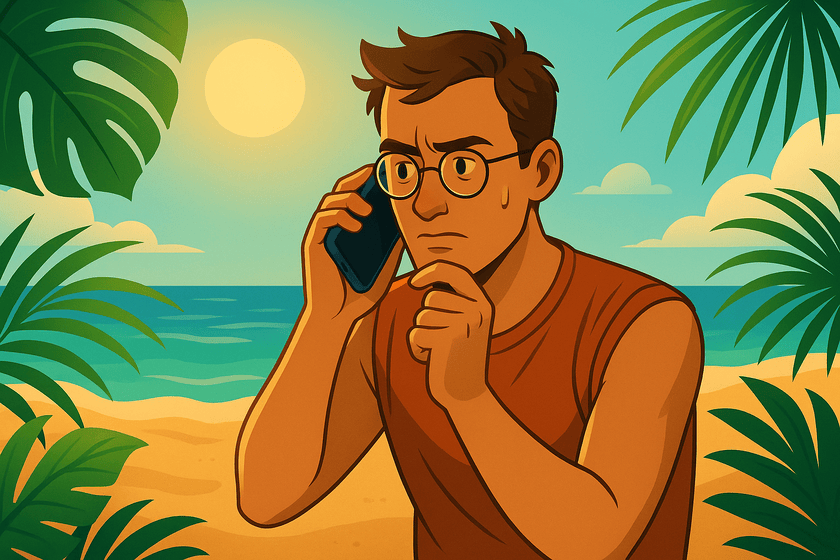

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


*   Czy wszystkie kolumny są istotne w kontekście zadania?

Kolumna Ticket zawierająca numer biletu nie ma znaczenia.

* Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)

Uzupełnie je modą dla danych kategorialnych, a dla numerycznych medianą. W kolumnie cabin są ogromne braki, więc lepiej jej nie wypełniać - brak przypisanego pokoju też może dać nam jakieś informacje.

* Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)

Do trenowania modelu najlepiej użyć samych danych numerycznych.

* Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne?

Wszystkie dane numeryczne są asymetryczne. Kategorialne również nie są zbalansowane.

* Która zmienna oznacza predykowaną klasę?

Survived

* Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych?

Można odczytać z wykresów.

* Czy końcowe rozkłady zawierają wartości skrajne?

Tak, jest dużo outlierów.


In [93]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [94]:
def get_percentage_missing(df, axis):
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]

missing = get_percentage_missing(titanic_df, axis=0)
print(missing)

Age         19.87
Fare        11.00
Cabin       77.10
Embarked     0.22
dtype: float64


In [95]:
# wiek zależny od płci oraz klasy
grouped_age = titanic_df.groupby(['Sex', 'Pclass'])['Age']

fare_median = titanic_df['Fare'].median()
embarked_mode = titanic_df['Embarked'].mode()[0]

# wypełnianie
titanic_df['Age'] = titanic_df['Age'].fillna(grouped_age.transform('median'))
titanic_df['Fare'] = titanic_df['Fare'].fillna(fare_median)
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(embarked_mode)
titanic_df['Cabin'] = titanic_df['Cabin'].str[0].fillna('Unknown')

missing = get_percentage_missing(titanic_df, axis=0)

# nowe kolumny
titanic_df['Title'] = titanic_df['Name'].str.extract(' ([A-Za-z]+)\\.', expand=False)
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1
titanic_df['IsAlone'] = 0
titanic_df.loc[titanic_df['FamilySize'] == 1, 'IsAlone'] = 1

# usunięcie mało ważnych / zasugerownych w komentarzach - family size łączy SibSp i Parch
titanic_df = titanic_df.drop(columns=['Name', 'Ticket', 'SibSp', 'Parch'])

In [96]:
print(titanic_df.dtypes)
print(titanic_df['Title'].value_counts())

Survived        int64
Pclass          int64
Sex            object
Age           float64
Fare          float64
Cabin          object
Embarked       object
Title          object
FamilySize      int64
IsAlone         int64
dtype: object
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [97]:
rare_titles = ['Dr','Rev','Col','Major','Don','Lady','Sir','Capt','Countess','Jonkheer','Mlle','Ms','Mme']
titanic_df['Title'] = titanic_df['Title'].replace(rare_titles, 'Rare')
print(titanic_df['Title'].value_counts())

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


In [98]:
# Jednak powinny być jako int. Category jest dobre do początkowej analizy, ale do nauki modelu lepiej sprawdzi się int.
# titanic_df['Survived'] = titanic_df['Survived'].astype('category')
# titanic_df['Pclass'] = titanic_df['Pclass'].astype('category')
# titanic_df['Sex'] = titanic_df['Sex'].astype('category')
# titanic_df['IsAlone'] = titanic_df['IsAlone'].astype('category')

In [99]:
!pip install matplotlib
from matplotlib import pyplot as plt

In [100]:
!pip install seaborn
import seaborn as sns

<Axes: >

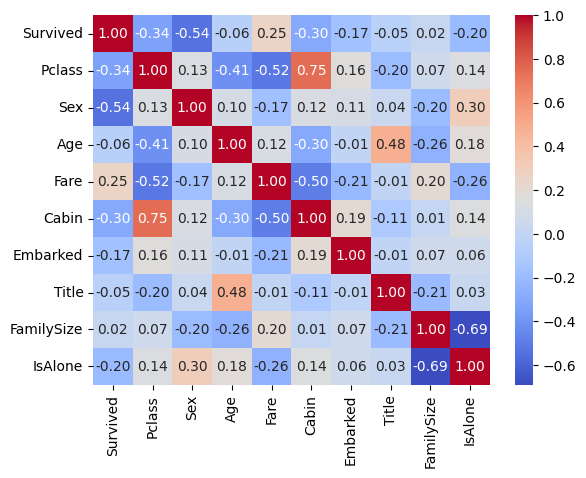

In [101]:
# bez kodowania one-hot wykres jest dużo bardziej czytelny
labels = titanic_df.columns
heatmap_df = titanic_df.copy()

# potrzebujemy same wartości liczowe
object_columns = heatmap_df.select_dtypes(include=['object']).columns
for col in object_columns:
    heatmap_df[col] = heatmap_df[col].astype('category').cat.codes
corr = heatmap_df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

In [102]:
# kodowanie
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})
  # one-hot
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True, dtype=int)
titanic_df = pd.get_dummies(titanic_df, columns=['Cabin'], drop_first=True, dtype=int)
titanic_df = pd.get_dummies(titanic_df, columns=['Title'], drop_first=True, dtype=int)


In [103]:
def plot_numeric_column(df, column_name, bins):
    data = df[column_name].dropna()
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=bins, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_categorical_column(df, column_name):
    counts = df[column_name].value_counts()

    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()


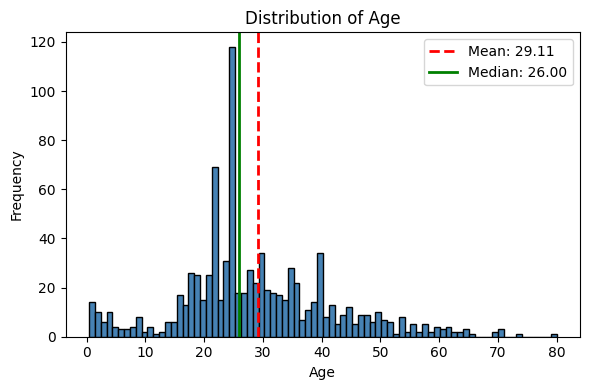

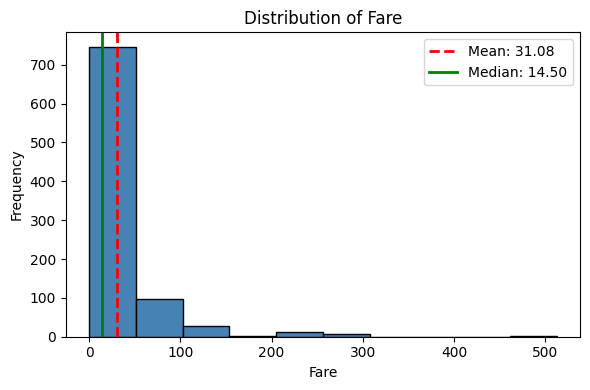

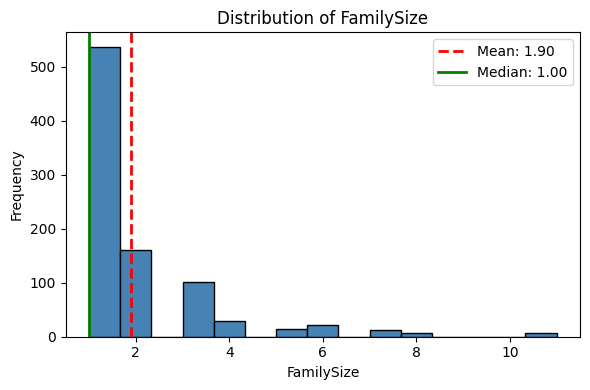

In [104]:
plot_numeric_column(titanic_df, 'Age', 80)
plot_numeric_column(titanic_df, 'Fare', 10)
plot_numeric_column(titanic_df, 'FamilySize', 15)

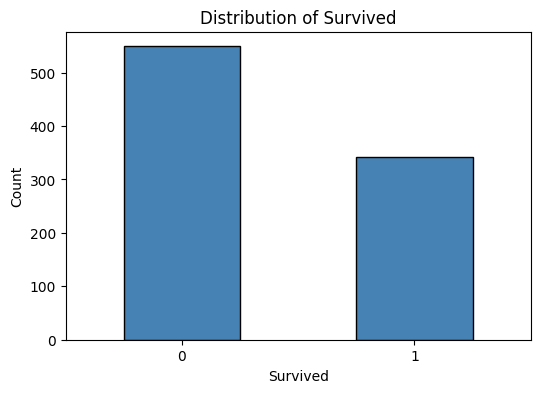

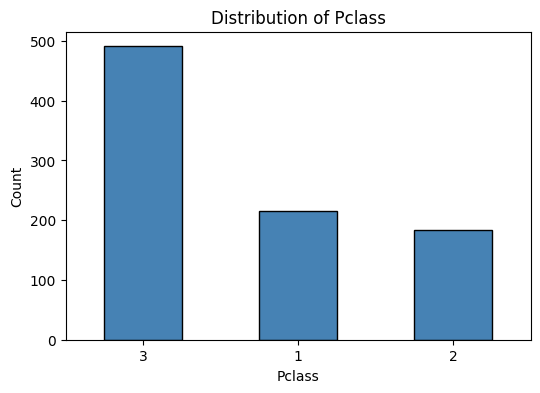

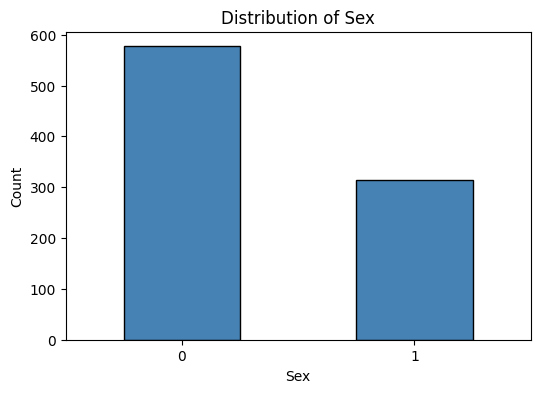

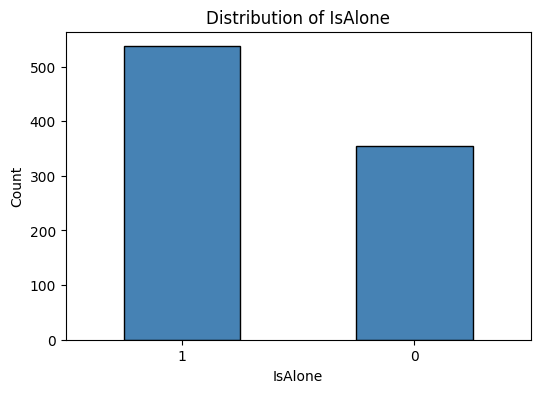

In [105]:
plot_categorical_column(titanic_df, 'Survived')
plot_categorical_column(titanic_df, 'Pclass')
plot_categorical_column(titanic_df, 'Sex')
plot_categorical_column(titanic_df, 'IsAlone')

Wykres wieku jest zaburzony przez wypełnione wartości, można jednak zauważyć, ze na pokładzie było sporo dzieci oraz bardzo dużo osób w średnim wieku. Najtańszych biletów zostało kupione najwięcej. Więcej ludzi podróżowało bez rodziny. Przeżyło około 300 osób, zginęło ponad 500. Około połowa ludzi podróżowała 3 klasą. Na statku było więcej mężczyzn niż kobiet.

In [106]:
def plot_categorical_vs_target(df, target, col_to_analyze):
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))
  sns.countplot(
      data=df,
      x=col_to_analyze,
      hue=target,
      ax=axes[0]
  )
  axes[0].set_title(f'Count of Survived by {col_to_analyze}')

  sns.barplot(
      data=df,
      x=col_to_analyze,
      y=target,
      ax=axes[1]
  )
  axes[1].set_title(f'{target} Rate by {col_to_analyze}')
  axes[1].set_ylabel(f'{target} Probability')

  plt.tight_layout()
  plt.show()

def plot_numeric_vs_target(df, target_col, col_to_analyze):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(
        data=df,
        x=col_to_analyze,
        hue=target_col,
        kde=True,
        element="step",
        ax=axes[0]
    )
    axes[0].set_title(f'Rozkład zmiennej {col_to_analyze} w podziale na {target_col}')
    axes[0].set_ylabel('Liczebność')

    sns.boxplot(
        data=df,
        x=target_col,
        y=col_to_analyze,
        ax=axes[1]
    )
    axes[1].set_title(f'Wykres pudełkowy (Boxplot) dla {col_to_analyze} vs {target_col}')

    plt.tight_layout()
    plt.show()

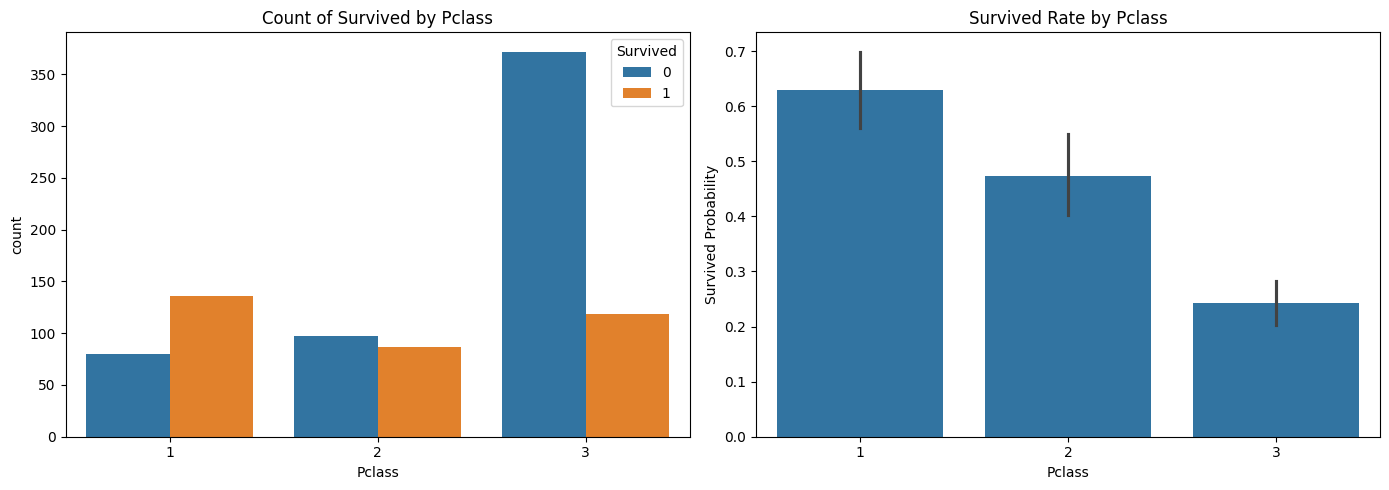

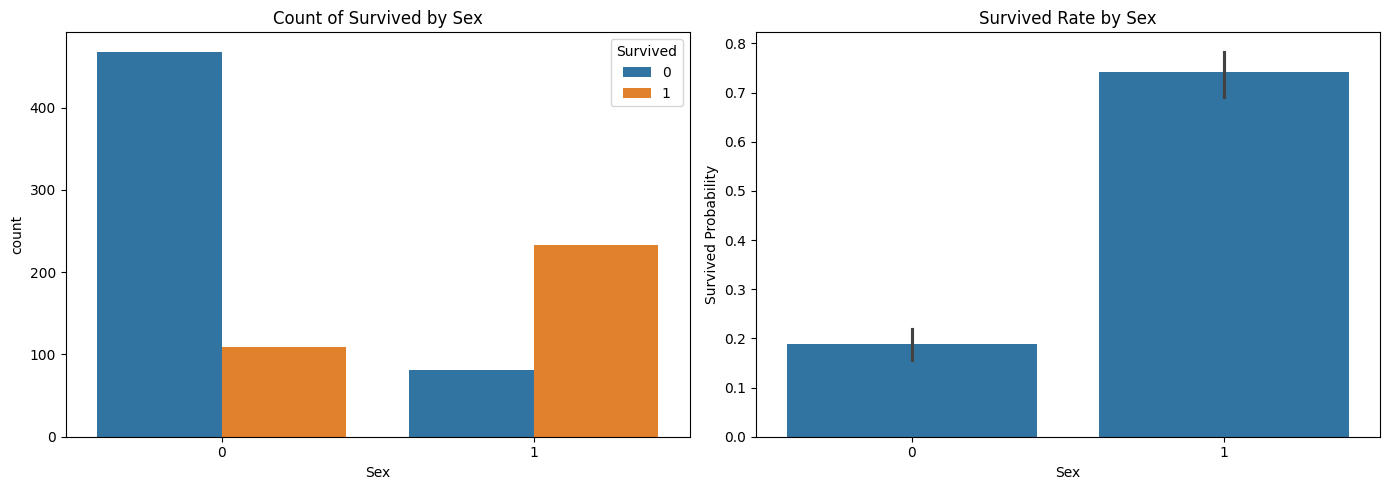

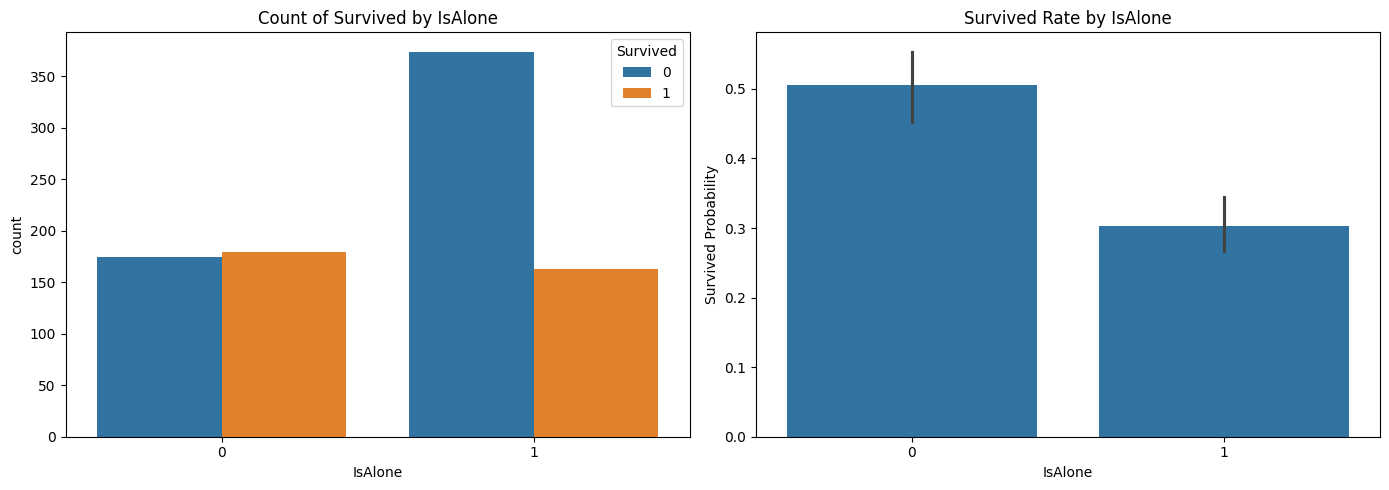

In [107]:
plot_categorical_vs_target(titanic_df, 'Survived', 'Pclass')
plot_categorical_vs_target(titanic_df, 'Survived', 'Sex')
plot_categorical_vs_target(titanic_df, 'Survived', 'IsAlone')

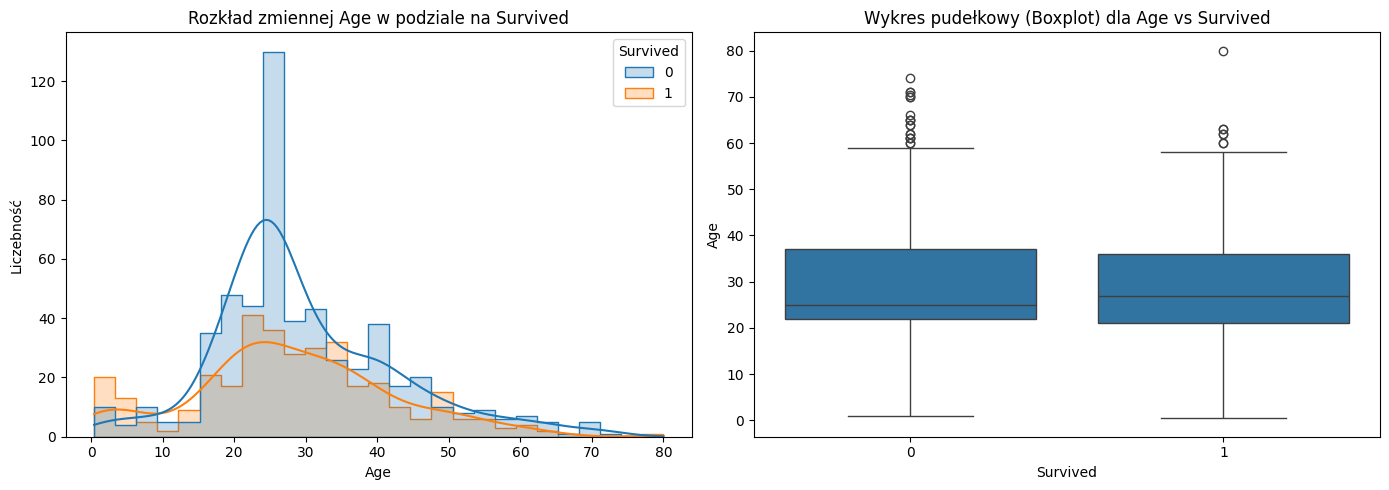

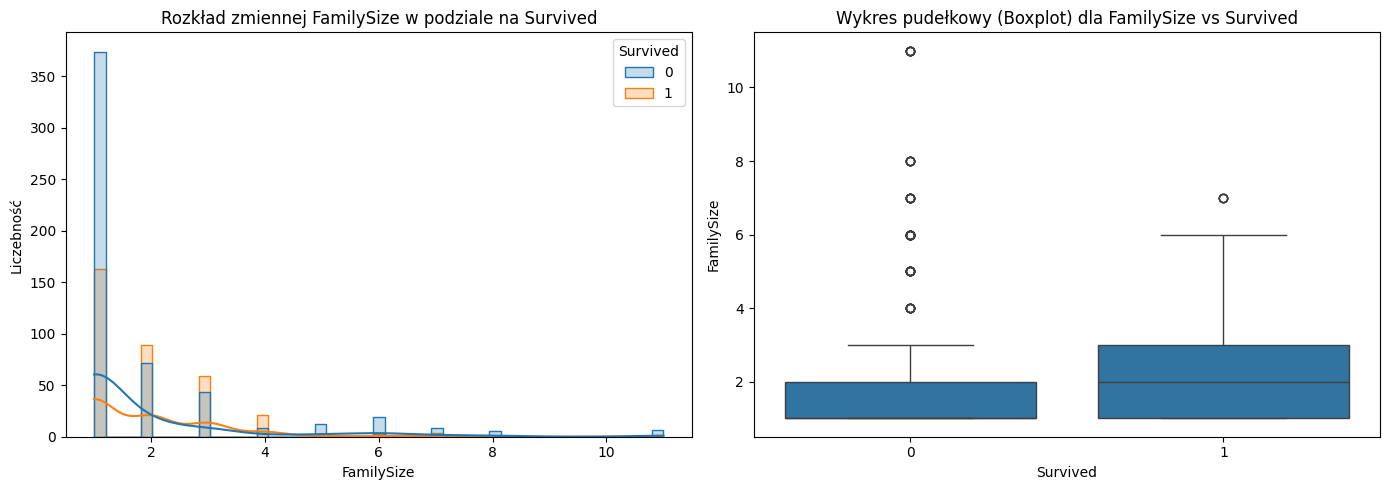

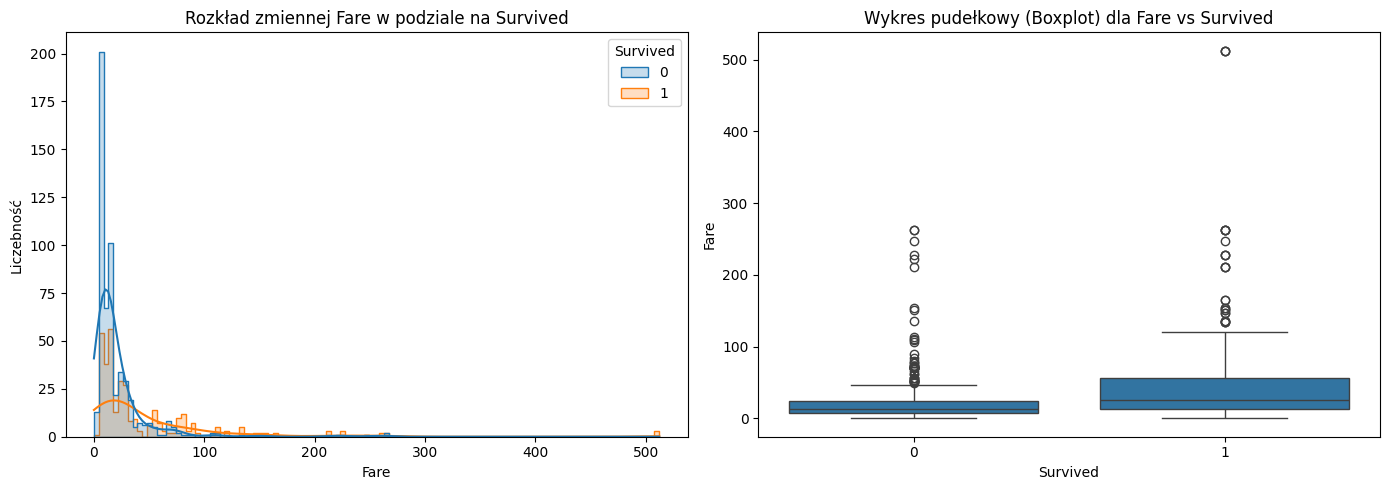

In [108]:
plot_numeric_vs_target(titanic_df, 'Survived', 'Age')
plot_numeric_vs_target(titanic_df, 'Survived', 'FamilySize')
plot_numeric_vs_target(titanic_df, 'Survived', 'Fare')

Podróżujący 1 klasą mieli największe szanse na przetrwanie. Kobiety miały większe szanse na przetrwanie. Ci, którzy mieli rodzine częściej przeżywali.
Jeśli chodzi o wiek, to małe dzieci przeżywały częściej niż ludzi w innych grupach wiekowych. Ludzie z małymi rodzinami mieli większą szanse na przeżycie. Droższy bilet oznaczał większą szanse na przeżycie.

In [111]:
# Szukanie skrajnych wartości
numeric_cols = ['Age', 'Fare']

print("outliery numeryczne")
for col in numeric_cols:
    Q1 = titanic_df[col].quantile(0.25)
    Q3 = titanic_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = titanic_df[(titanic_df[col] < lower_bound) | (titanic_df[col] > upper_bound)]
    print(f"{col}: ma {len(outliers)} wartości skrajnych")


discrete_cols = ['FamilySize',]

for col in discrete_cols:
    proportions = titanic_df[col].value_counts(normalize=True) * 100

    rare_values = proportions[proportions < 1.0].index.tolist()

    if rare_values:
        print(f"{col}: wartości skrajne to {rare_values}")
    else:
        print(f"{col}: brak skrajnych wartości.")

outliery numeryczne
Age: ma 33 wartości skrajnych
Fare: ma 110 wartości skrajnych
FamilySize: wartości skrajne to [11, 8]


Wszędzie występują wartości skrajne.